In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  0. IMPORTS & DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
})
C = dict(red='#e74c3c', blue='#2980b9', green='#27ae60',
         orange='#f39c12', purple='#8e44ad', grey='#95a5a6')

# ── Load all files ────────────────────────────────────────────────────────────
print('Loading data...')
orders      = pd.read_csv('orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv('order_items.csv', dtype={'promo_id': str, 'promo_id_2': str})
products    = pd.read_csv('products.csv')
promotions  = pd.read_csv('promotions.csv')
payments    = pd.read_csv('payments.csv')
returns     = pd.read_csv('returns.csv')
customers   = pd.read_csv('customers.csv')
geography   = pd.read_csv('geography.csv')
inventory   = pd.read_csv('inventory.csv')
web_traffic = pd.read_csv('web_traffic.csv')
sales       = pd.read_csv('sales.csv', parse_dates=['Date'])
print('Done!')

# ── Revenue per order (reused across insights) ────────────────────────────────
order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price']
ord_rev = order_items.groupby('order_id')['line_revenue'].sum().reset_index(name='revenue')

print(f"\nOrders   : {len(orders):,} orders  |  {orders['customer_id'].nunique():,} customers")
print(f"Date range: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")
print(f"Order status:\n{orders['order_status'].value_counts().to_string()}")


Loading data...
Done!

Orders   : 646,945 orders  |  90,246 customers
Date range: 2012-07-04 → 2022-12-31
Order status:
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275


             n_lines  unit_price_avg  cogs_avg  gross_margin  discount_avg  net_profit_avg
promo_label                                                                               
No Promo      438353          5575.0    4461.0        5007.0           0.0          5007.0
fixed          20950          3983.0    6415.0      -11004.0         226.0        -11229.0
percentage    255366          4417.0    4153.0        1185.0        2917.0         -1732.0


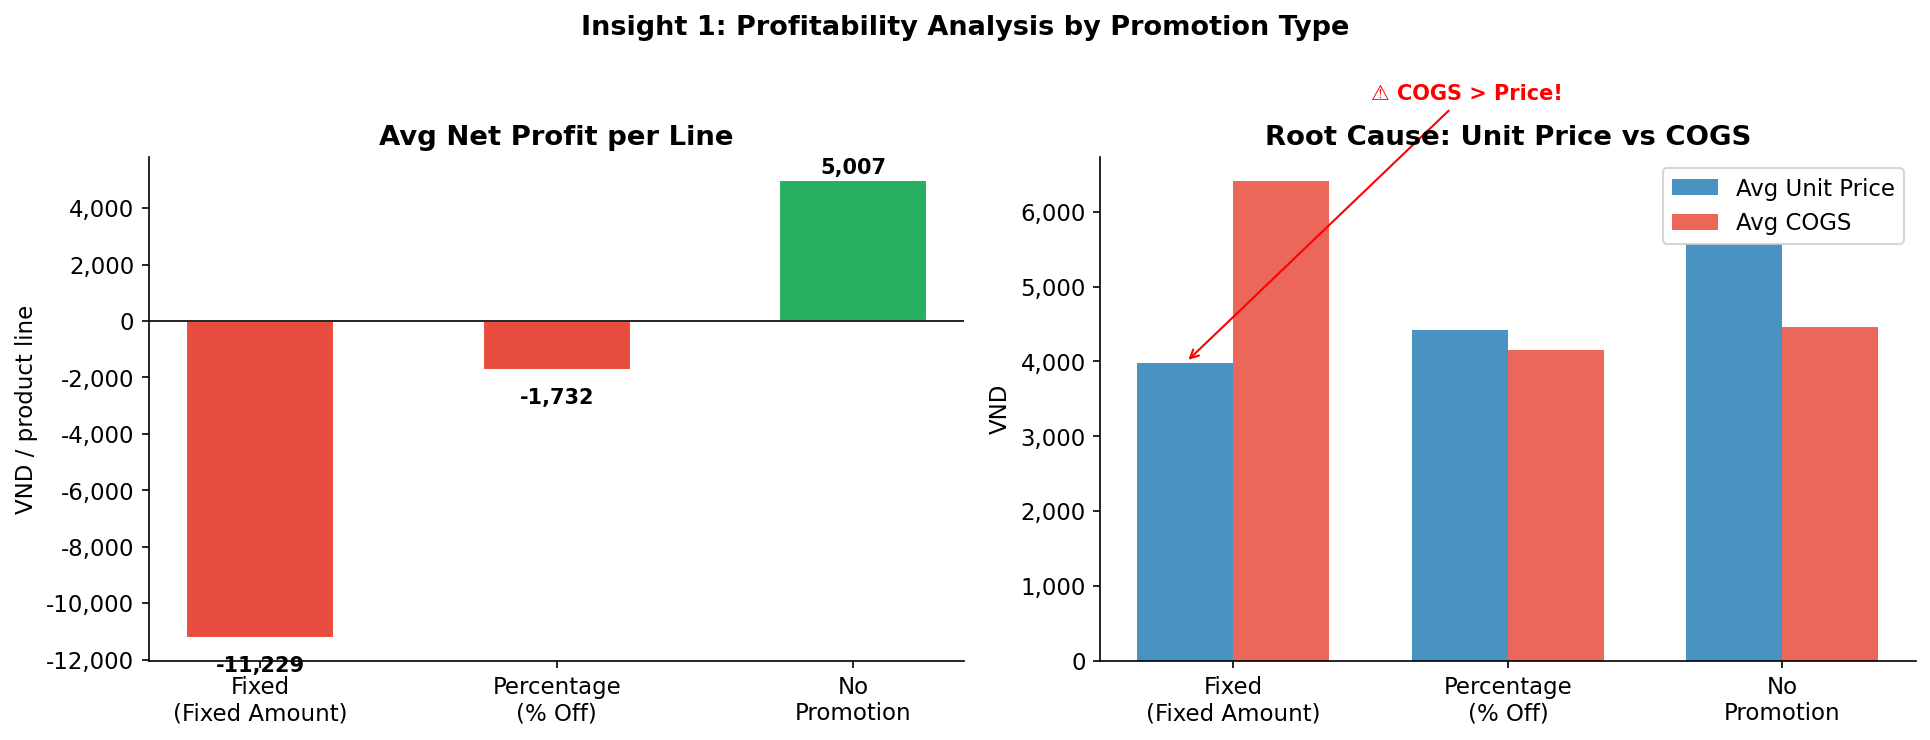

In [2]:
# ── INSIGHT 1: Profitability by Promotion Type ───────────────────────────────
m1 = (order_items
      .merge(products[['product_id','cogs','price','category','segment']], on='product_id', how='left')
      .merge(promotions[['promo_id','promo_type']], on='promo_id', how='left'))
m1['discount_amount'] = m1['discount_amount'].fillna(0)
m1['gross_margin'] = (m1['quantity'] * m1['unit_price']) - (m1['quantity'] * m1['cogs'])
m1['net_profit']   = m1['gross_margin'] - m1['discount_amount']
m1['promo_label']  = m1['promo_type'].fillna('No Promo')

summary = m1.groupby('promo_label').agg(
    n_lines        = ('net_profit', 'count'),
    unit_price_avg = ('unit_price', 'mean'),
    cogs_avg       = ('cogs', 'mean'),
    gross_margin   = ('gross_margin', 'mean'),
    discount_avg   = ('discount_amount', 'mean'),
    net_profit_avg = ('net_profit', 'mean')
).round(0)
print(summary.to_string())

# ── Chart ─────────────────────────────────────────────────────────────────────
ORDER  = ['fixed', 'percentage', 'No Promo']
XLBLS  = ['Fixed\n(Fixed Amount)', 'Percentage\n(% Off)', 'No\nPromotion']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Insight 1: Profitability Analysis by Promotion Type', fontweight='bold', fontsize=13)

# Net profit
np_vals = [summary.loc[g, 'net_profit_avg'] for g in ORDER]
clrs1   = [C['red'] if v < 0 else C['green'] for v in np_vals]
bars    = axes[0].bar(XLBLS, np_vals, color=clrs1, width=0.5, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('VND / product line')
axes[0].set_title('Avg Net Profit per Line', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, np_vals):
    offset = -1200 if val < 0 else 200
    axes[0].text(bar.get_x()+bar.get_width()/2, val+offset,
                 f'{val:,.0f}', ha='center', fontweight='bold', fontsize=10)

# Unit price vs COGS – root cause
x  = np.arange(len(ORDER))
w  = 0.35
pv = [summary.loc[g, 'unit_price_avg'] for g in ORDER]
cv = [summary.loc[g, 'cogs_avg']       for g in ORDER]
axes[1].bar(x-w/2, pv, w, label='Avg Unit Price', color=C['blue'],   alpha=0.85)
axes[1].bar(x+w/2, cv, w, label='Avg COGS',       color=C['red'],    alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(XLBLS)
axes[1].set_ylabel('VND')
axes[1].set_title('Root Cause: Unit Price vs COGS', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].legend()
axes[1].annotate('⚠️ COGS > Price!', xy=(0-w/2, pv[0]),
                  xytext=(0.5, 7500),
                  arrowprops=dict(arrowstyle='->', color='red'),
                  fontsize=10, color='red', fontweight='bold')
plt.tight_layout()
plt.savefig('insight1_promo.png', dpi=150, bbox_inches='tight')
plt.show()


Correlation page_views ↔ stockout  : r = 0.827
Correlation page_views ↔ overstock : r = 0.076


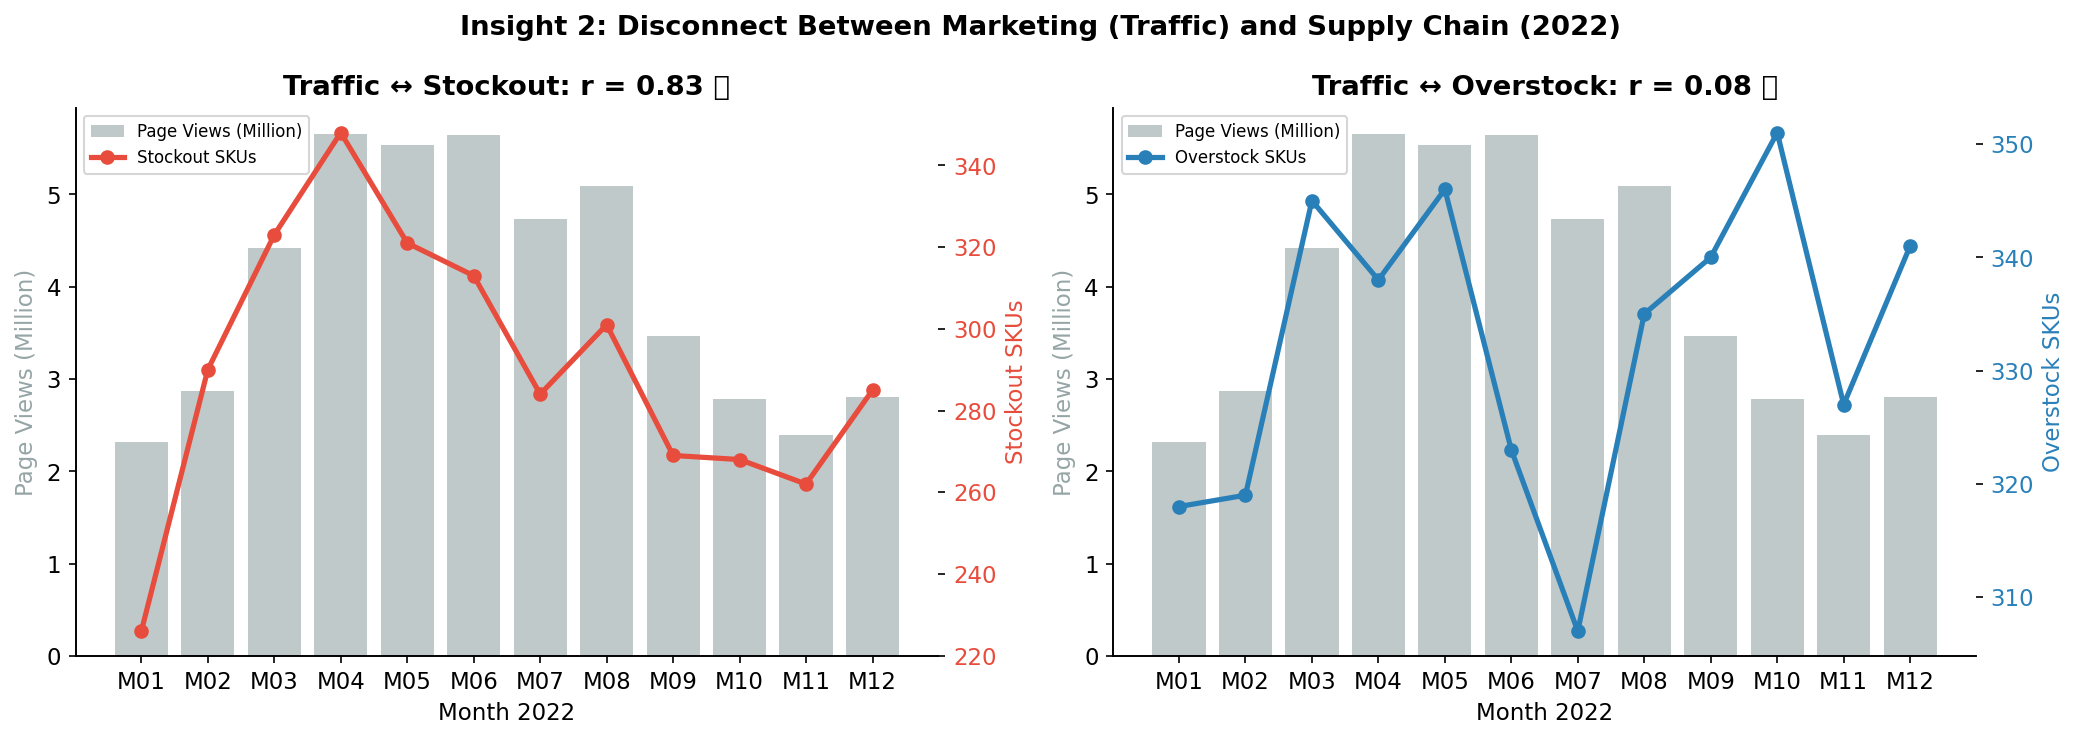

In [3]:
# ── INSIGHT 2: Traffic vs Inventory ──────────────────────────────────────────
inv = inventory.copy()
inv['month_year'] = pd.to_datetime(inv['snapshot_date']).dt.to_period('M').astype(str)
web = web_traffic.copy()
web['month_year'] = pd.to_datetime(web['date']).dt.to_period('M').astype(str)

inv_m = inv.groupby('month_year').agg(
    stockout  = ('stockout_flag',  'sum'),
    overstock = ('overstock_flag', 'sum')
).reset_index()
web_m = web.groupby('month_year')['page_views'].sum().reset_index()
m22   = inv_m.merge(web_m, on='month_year').query("month_year.str.startswith('2022')")
m22['month'] = m22['month_year'].str[-2:]

r_stock = m22['page_views'].corr(m22['stockout'])
r_over  = m22['page_views'].corr(m22['overstock'])
print(f'Correlation page_views ↔ stockout  : r = {r_stock:.3f}')
print(f'Correlation page_views ↔ overstock : r = {r_over:.3f}')

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Insight 2: Disconnect Between Marketing (Traffic) and Supply Chain (2022)',
             fontweight='bold')
xlbls = [f'M{m}' for m in m22['month']]

for ax, flag, clr, label, r_val, symbol in [
    (axes[0], 'stockout',  C['red'],  'Stockout SKUs',  r_stock, '✅'),
    (axes[1], 'overstock', C['blue'], 'Overstock SKUs', r_over,  '❌'),
]:
    axb = ax.twinx()
    ax.bar(xlbls, m22['page_views']/1e6, color=C['grey'], alpha=0.6, label='Page Views (Million)')
    axb.plot(xlbls, m22[flag], color=clr, marker='o', lw=2.5, label=label)
    ax.set_ylabel('Page Views (Million)', color=C['grey'])
    axb.set_ylabel(label, color=clr)
    axb.tick_params(axis='y', labelcolor=clr)
    ax.set_title(f'Traffic ↔ {flag.title()}: r = {r_val:.2f} {symbol}', fontweight='bold')
    ax.set_xlabel('Month 2022')
    l1, lb1 = ax.get_legend_handles_labels()
    l2, lb2 = axb.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('insight2_supplychain.png', dpi=150, bbox_inches='tight')
plt.show()


order_status     total  cancel_rate  return_rate  deliver_rate
payment_method                                                
cod              96681         16.0          8.9          69.7
paypal           97018          8.1          5.0          81.6
apple_pay        64763          8.0          5.0          81.6
credit_card     356352          8.0          5.0          81.7
bank_transfer    32131          7.9          5.0          81.7

Top return reason: wrong_size (35.0%)


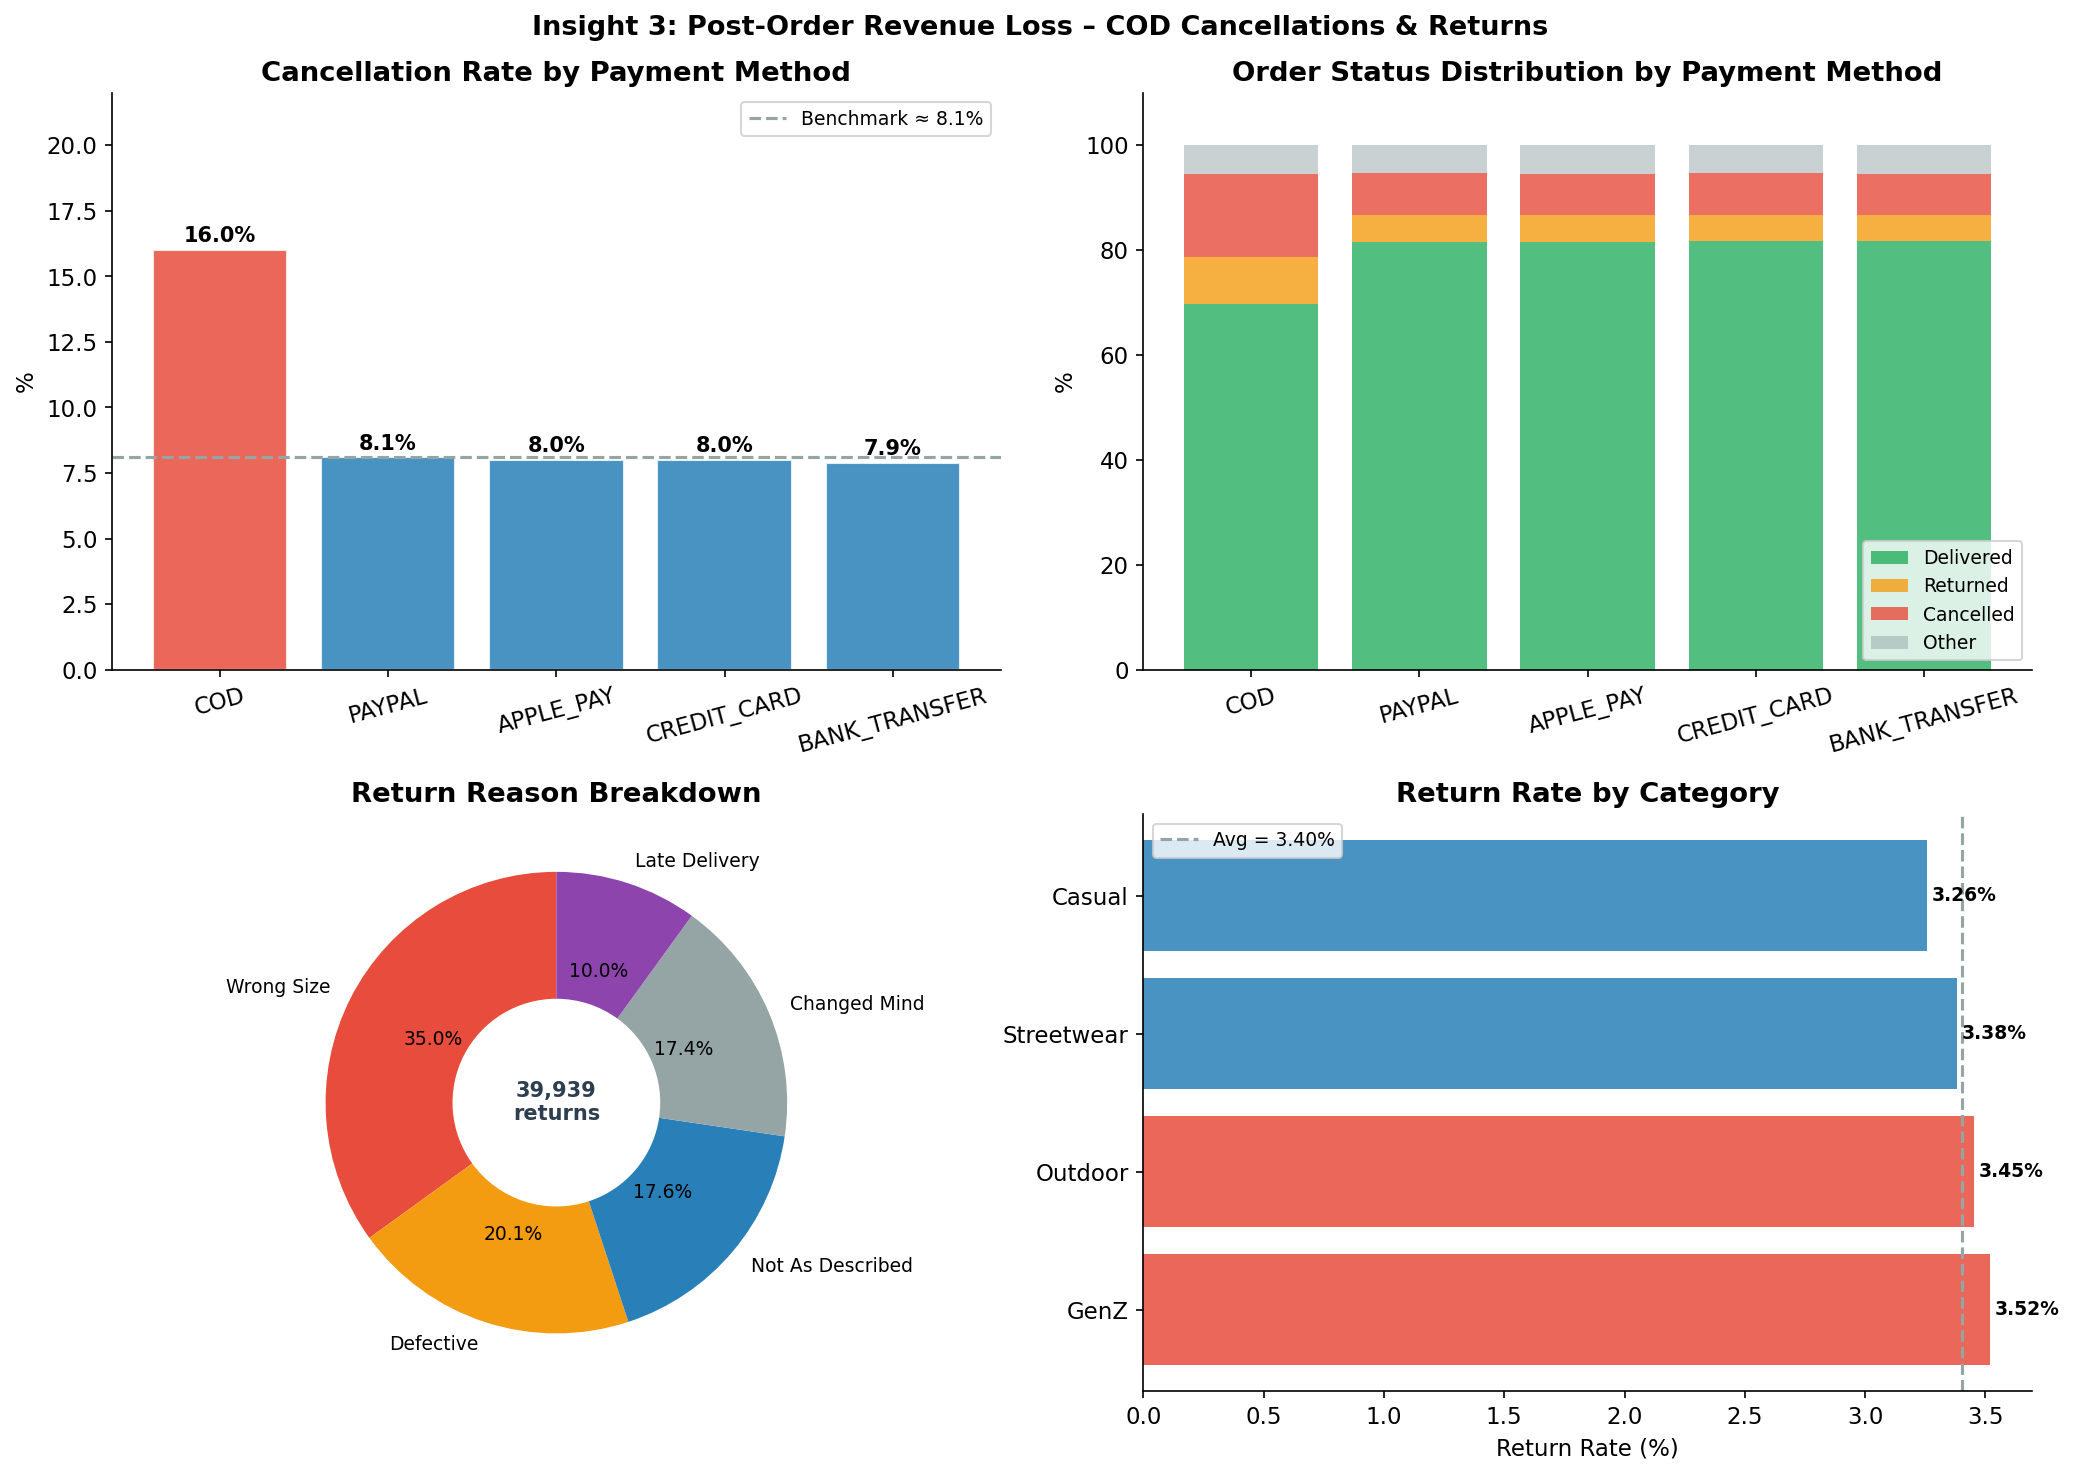

In [4]:
# ── INSIGHT 3: COD Cancellation + Return Root Cause ──────────────────────────
import numpy as np

# ── COD Analysis ──────────────────────────────────────────────────────────────
pm_status = (orders.groupby('payment_method')['order_status']
               .value_counts().unstack(fill_value=0))
pm_status['total']        = pm_status.sum(axis=1)
pm_status['cancel_rate']  = pm_status['cancelled'] / pm_status['total'] * 100
pm_status['return_rate']  = pm_status['returned']  / pm_status['total'] * 100
pm_status['deliver_rate'] = pm_status['delivered'] / pm_status['total'] * 100
pm_plot = pm_status[['total','cancel_rate','return_rate','deliver_rate']].round(1) \
                   .sort_values('cancel_rate', ascending=False)

# ── Return Analysis ───────────────────────────────────────────────────────────
ret_prod = returns.merge(products[['product_id','category']], on='product_id', how='left')
sold_cat = order_items.merge(products[['product_id','category']], on='product_id') \
                      .groupby('category')['quantity'].sum()
ret_cat  = ret_prod.groupby('category')['return_quantity'].sum()
rr_cat   = (ret_cat / sold_cat * 100).dropna().sort_values(ascending=False)
reason_vc = returns['return_reason'].value_counts()

print(pm_plot.to_string())
print(f"\nTop return reason: {reason_vc.index[0]} ({reason_vc.iloc[0]/len(returns)*100:.1f}%)")

# ── 2×2 Chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Insight 3: Post-Order Revenue Loss – COD Cancellations & Returns',
             fontweight='bold', fontsize=13)

pm_names  = pm_plot.index.tolist()
cancel_v  = pm_plot['cancel_rate'].values
return_v  = pm_plot['return_rate'].values
deliver_v = pm_plot['deliver_rate'].values
other_v   = 100 - cancel_v - return_v - deliver_v
bar_clrs  = [C['red'] if n == 'cod' else C['blue'] for n in pm_names]
x_pos     = np.arange(len(pm_names))

# [0,0] Cancellation rate by payment method
bars1 = axes[0,0].bar(pm_names, cancel_v, color=bar_clrs, alpha=0.85, edgecolor='white')
axes[0,0].axhline(cancel_v[1], color=C['grey'], lw=1.5, ls='--',
                  label=f'Benchmark ≈ {cancel_v[1]:.1f}%')
axes[0,0].set_title('Cancellation Rate by Payment Method', fontweight='bold')
axes[0,0].set_ylabel('%'); axes[0,0].set_ylim(0, 22)
axes[0,0].set_xticklabels([n.upper() for n in pm_names], rotation=15)
axes[0,0].legend(fontsize=9)
for bar, v in zip(bars1, cancel_v):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                   f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# [0,1] Stacked order status
axes[0,1].bar(x_pos, deliver_v, label='Delivered',  color=C['green'],  alpha=0.8)
axes[0,1].bar(x_pos, return_v,  bottom=deliver_v,
              label='Returned',  color=C['orange'], alpha=0.8)
axes[0,1].bar(x_pos, cancel_v,  bottom=deliver_v+return_v,
              label='Cancelled', color=C['red'],    alpha=0.8)
axes[0,1].bar(x_pos, other_v,   bottom=deliver_v+return_v+cancel_v,
              label='Other',     color=C['grey'],   alpha=0.5)
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels([n.upper() for n in pm_names], rotation=15)
axes[0,1].set_ylabel('%'); axes[0,1].set_ylim(0, 110)
axes[0,1].set_title('Order Status Distribution by Payment Method', fontweight='bold')
axes[0,1].legend(fontsize=9, loc='lower right')

# [1,0] Return reason donut
reason_labels  = [r.replace('_',' ').title() for r in reason_vc.index]
REASON_COLORS  = [C['red'], C['orange'], C['blue'], C['grey'], C['purple']]
axes[1,0].pie(reason_vc.values, labels=reason_labels, autopct='%1.1f%%',
              colors=REASON_COLORS, startangle=90,
              wedgeprops=dict(width=0.55), textprops={'fontsize': 9})
axes[1,0].set_title('Return Reason Breakdown', fontweight='bold')
axes[1,0].text(0, 0, f'{len(returns):,}\nreturns', ha='center', va='center',
               fontsize=10, fontweight='bold', color='#2c3e50')

# [1,1] Return rate by category
mean_rr    = rr_cat.mean()
cat_colors = [C['red'] if v > mean_rr else C['blue'] for v in rr_cat.values]
axes[1,1].barh(rr_cat.index, rr_cat.values, color=cat_colors, alpha=0.85)
axes[1,1].axvline(mean_rr, color=C['grey'], lw=1.5, ls='--',
                  label=f'Avg = {mean_rr:.2f}%')
axes[1,1].set_xlabel('Return Rate (%)')
axes[1,1].set_title('Return Rate by Category', fontweight='bold')
axes[1,1].legend(fontsize=9)
for i, v in enumerate(rr_cat.values):
    axes[1,1].text(v+0.02, i, f'{v:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('insight3_order_risk.png', dpi=150, bbox_inches='tight')
plt.show()


Cities needed to reach 80% revenue: 28/42 (67%)

Revenue by region:
region
East       46.5
Central    30.1
West       23.4
Name: revenue, dtype: float64


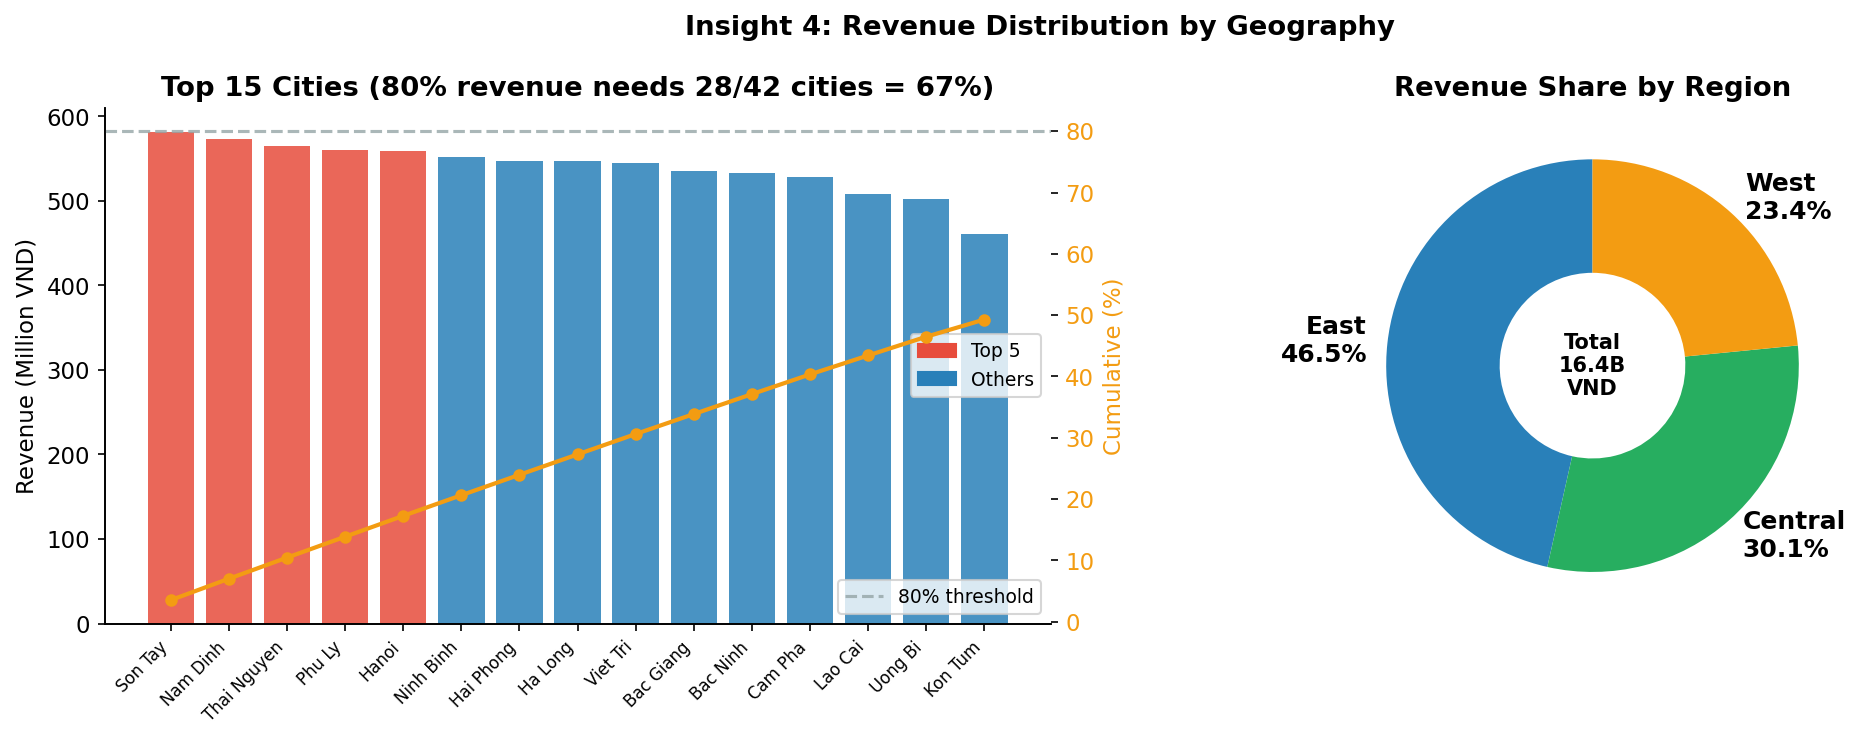

In [5]:
# ── INSIGHT 4: Geography Pareto ───────────────────────────────────────────────
zip_geo   = geography[['zip','city','region']].drop_duplicates('zip')
df_pareto = (orders[['order_id','zip']]
             .merge(zip_geo, on='zip', how='left')
             .merge(ord_rev, on='order_id', how='inner'))

city_rev = (df_pareto.groupby('city')['revenue'].sum()
                     .sort_values(ascending=False).reset_index())
city_rev['cum_pct'] = city_rev['revenue'].cumsum() / city_rev['revenue'].sum() * 100
n80 = (city_rev['cum_pct'] <= 80).sum() + 1
print(f'Cities needed to reach 80% revenue: {n80}/{len(city_rev)} ({n80/len(city_rev)*100:.0f}%)')

region_rev  = df_pareto.groupby('region')['revenue'].sum().sort_values(ascending=False)
region_pct  = region_rev / region_rev.sum() * 100
print('\nRevenue by region:')
print(region_pct.round(1))

# ── Chart ─────────────────────────────────────────────────────────────────────
top15 = city_rev.head(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Insight 4: Revenue Distribution by Geography', fontweight='bold')

# Pareto chart
bar_c  = [C['red'] if i < 5 else C['blue'] for i in range(15)]
axes[0].bar(range(15), top15['revenue']/1e6, color=bar_c, alpha=0.85)
ax0b = axes[0].twinx()
ax0b.plot(range(15), top15['cum_pct'], color=C['orange'], marker='o', ms=5, lw=2)
ax0b.axhline(80, color=C['grey'], ls='--', alpha=0.8, label='80% threshold')
ax0b.legend(fontsize=9)
ax0b.set_ylabel('Cumulative (%)', color=C['orange'])
ax0b.tick_params(axis='y', labelcolor=C['orange'])
axes[0].set_xticks(range(15))
axes[0].set_xticklabels(top15['city'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Revenue (Million VND)')
axes[0].set_title(f'Top 15 Cities (80% revenue needs {n80}/{len(city_rev)} cities = {n80/len(city_rev)*100:.0f}%)',
                  fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend([Patch(color=C['red']), Patch(color=C['blue'])],
               ['Top 5', 'Others'], loc='center right', fontsize=9)

# Region donut
reg_colors = [C['blue'], C['green'], C['orange']]
axes[1].pie(region_pct.values,
            labels=[f"{r}\n{v:.1f}%" for r, v in zip(region_pct.index, region_pct.values)],
            colors=reg_colors, startangle=90, wedgeprops=dict(width=0.55),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
total_b = region_rev.sum()/1e9
axes[1].text(0, 0, f'Total\n{total_b:.1f}B\nVND', ha='center', va='center',
             fontsize=10, fontweight='bold')
axes[1].set_title('Revenue Share by Region', fontweight='bold')

plt.tight_layout()
plt.savefig('insight5_geo.png', dpi=150, bbox_inches='tight')
plt.show()


               n  recency_avg  freq_avg  monetary_avg
Segment                                              
Champions   9116        123.0      23.0      599778.0
Loyalists  23735        549.0      12.0      307465.0
Others     21298        683.0       3.0       74722.0
At Risk    36097       2344.0       2.0       57450.0


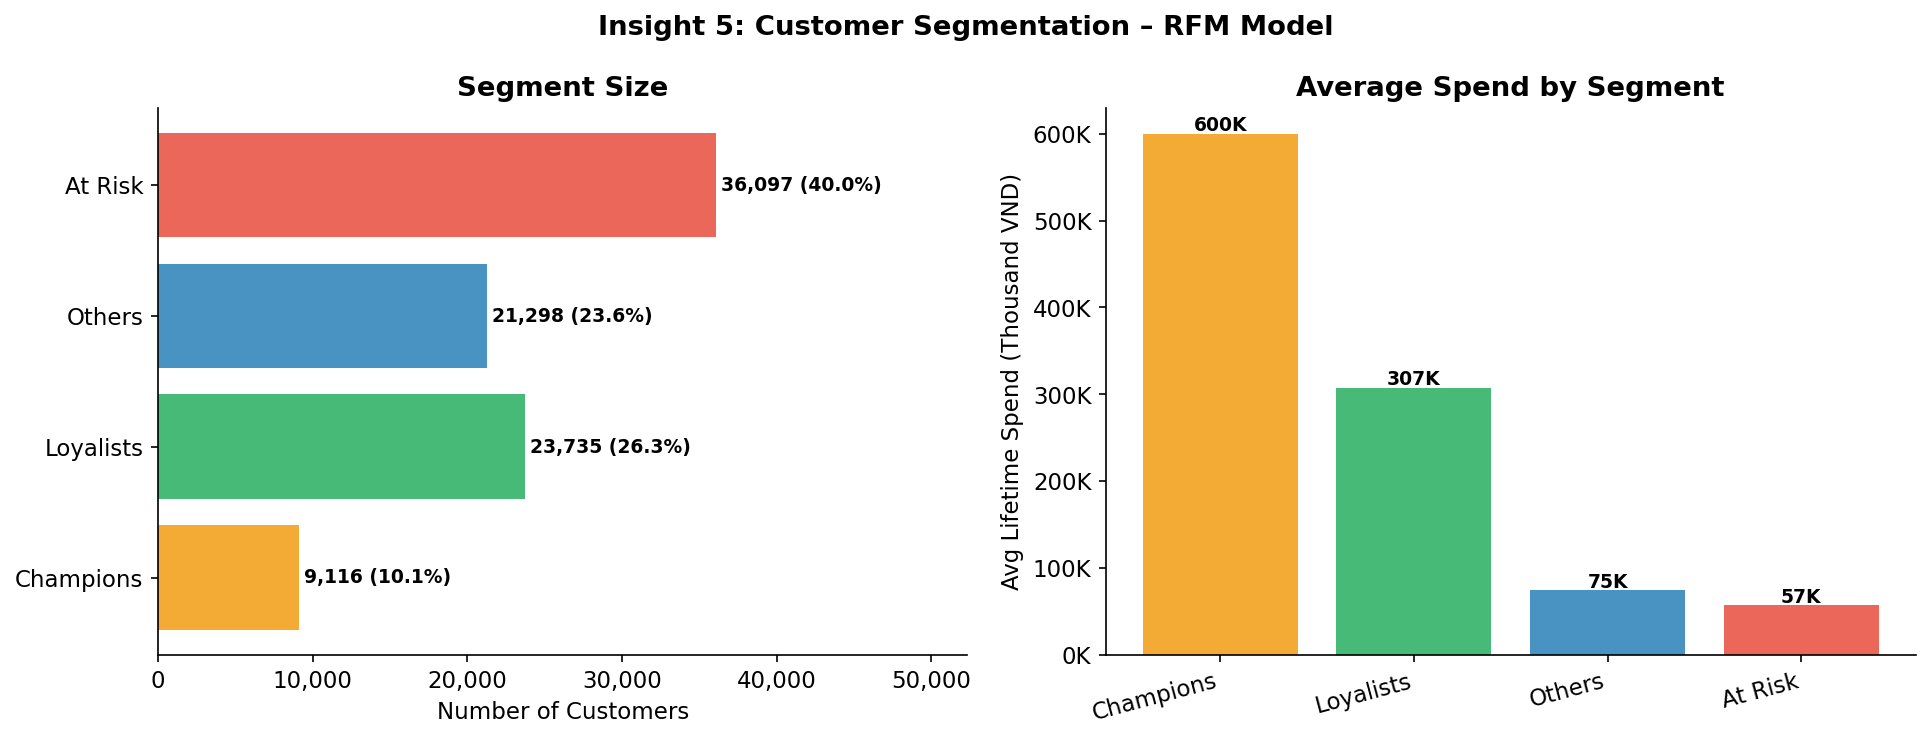

In [6]:
# ── INSIGHT 5: RFM Segmentation ───────────────────────────────────────────────
rfm_base = orders[['order_id','customer_id','order_date']].merge(ord_rev, on='order_id', how='inner')
NOW = rfm_base['order_date'].max() + pd.Timedelta(days=1)

rfm = rfm_base.groupby('customer_id').agg(
    Recency   = ('order_date', lambda x: (NOW-x.max()).days),
    Frequency = ('order_id', 'count'),
    Monetary  = ('revenue', 'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['Recency'],                          5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),   5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'],                         5, labels=[1,2,3,4,5])
rfm['RFM'] = rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)

def segment(row):
    if row['RFM'].startswith('55'): return 'Champions'
    if int(str(row['R'])) <= 2:      return 'At Risk'
    if int(str(row['F'])) >= 4:      return 'Loyalists'
    return 'Others'
rfm['Segment'] = rfm.apply(segment, axis=1)

seg_stat = rfm.groupby('Segment').agg(
    n=('customer_id','count'),
    recency_avg=('Recency','mean'),
    freq_avg=('Frequency','mean'),
    monetary_avg=('Monetary','mean')
).round(0).sort_values('monetary_avg', ascending=False)
print(seg_stat.to_string())

# ── Chart ─────────────────────────────────────────────────────────────────────
SEG_ORDER  = ['Champions','Loyalists','Others','At Risk']
SEG_COLORS = [C['orange'], C['green'], C['blue'], C['red']]
counts  = [rfm[rfm['Segment']==s].shape[0]               for s in SEG_ORDER]
mon_avg = [rfm[rfm['Segment']==s]['Monetary'].mean()/1000 for s in SEG_ORDER]
total   = sum(counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Insight 5: Customer Segmentation – RFM Model', fontweight='bold')

# Segment size
bars = axes[0].barh(SEG_ORDER, counts, color=SEG_COLORS, alpha=0.85)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_width()+300, bar.get_y()+bar.get_height()/2,
                 f'{cnt:,} ({cnt/total*100:.1f}%)', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlim(0, max(counts)*1.45)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Segment Size', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Avg spend
axes[1].bar(SEG_ORDER, mon_avg, color=SEG_COLORS, alpha=0.85)
axes[1].set_ylabel('Avg Lifetime Spend (Thousand VND)')
axes[1].set_title('Average Spend by Segment', fontweight='bold')
axes[1].set_xticklabels(SEG_ORDER, rotation=15, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
for i, v in enumerate(mon_avg):
    axes[1].text(i, v+3, f'{v:.0f}K', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('insight6_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
